In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

In [ ]:

df = pd.read_csv("/content/drive/MyDrive/Placement_Analyzer/student_placement_synthetic.csv")

df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [ ]:
# Dataset Shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 100000
Columns : 18


In [ ]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cgpa,100000.0,7.206381,0.925235,4.00,6.58,7.21,7.83,10.00
backlogs,100000.0,0.547010,0.862727,0.00,0.00,0.00,1.00,3.00
coding_skills,100000.0,5.995147,1.496302,1.00,5.00,6.00,7.00,10.00
dsa_score,100000.0,5.500711,1.781961,1.00,4.30,5.50,6.70,10.00
aptitude_score,100000.0,64.990511,11.990892,20.00,56.80,65.00,73.10,100.00
...,...,...,...,...,...,...,...,...
hackathons,100000.0,0.745840,0.884189,0.00,0.00,0.00,1.00,3.00
open_source_contributions,100000.0,0.450990,0.671061,0.00,0.00,0.00,1.00,2.00
extracurriculars,100000.0,1.151100,0.965162,0.00,0.00,1.00,2.00,3.00
placement_status,100000.0,0.684750,0.464618,0.00,0.00,1.00,1.00,1.00


In [ ]:
df.isnull().sum()

,0
branch,0
college_tier,0
cgpa,0
backlogs,0
coding_skills,0
...,...
hackathons,0
open_source_contributions,0
extracurriculars,0
placement_status,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop("salary_package_lpa", axis=1)

In [ ]:
corr = df.corr(numeric_only=True)

print(corr["placement_status"].sort_values(ascending=False))

placement_status             1.000000
cgpa                         0.148932
internships                  0.099967
coding_skills                0.087657
dsa_score                    0.086594
                               ...   
open_source_contributions    0.022723
ml_knowledge                 0.002097
system_design               -0.001583
extracurriculars            -0.004807
backlogs                    -0.058815
Name: placement_status, Length: 15, dtype: float64


#data preprocess

Salary = 0

↓

Model immediately knows

↓

Not Placed

In [ ]:
df["placement_status"].value_counts()


,count
placement_status,
1,68475
0,31525


In [ ]:
placement_percent = (
    df["placement_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(placement_percent)

placement_status
1    68.47
0    31.52
Name: proportion, dtype: float64


"Is your dataset balanced?"
Approximately 68.5% belong to the placed class and 31.5% to the not placed class. This represents a moderate class imbalance rather than a severe one. I initially trained the models on the original distribution and evaluated them using precision, recall, F1-score, and ROC-AUC. Since Random Forest handles moderate imbalance reasonably well, I did not apply oversampling or SMOTE unless the minority class performance required improvement."

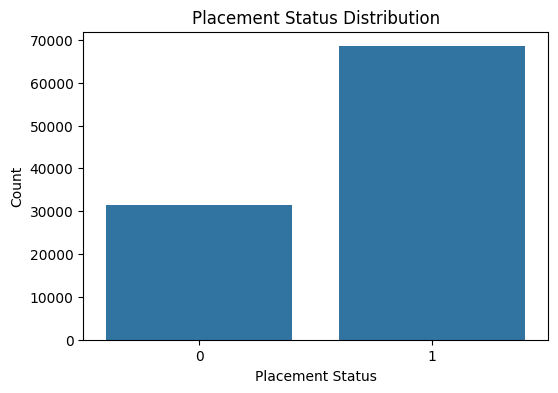

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="placement_status", data=df)

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Count")

plt.show()

In [ ]:
print(df["branch"].unique())
print(df["college_tier"].unique())

['ECE' 'Chemical' 'EE' 'CE' 'CSE' 'IT' 'ME']
['Tier-3' 'Tier-2' 'Tier-1']


##encoding branch,tier

In [ ]:
from sklearn.preprocessing import LabelEncoder

branch_encoder = LabelEncoder()

df["branch"] = branch_encoder.fit_transform(df["branch"])

tier_encoder = LabelEncoder()

df["college_tier"] = tier_encoder.fit_transform(df["college_tier"])

In [ ]:
mapping = pd.DataFrame({
    "Branch": branch_encoder.classes_,
    "Encoded Value": range(len(branch_encoder.classes_))
})

print(mapping)

     Branch  Encoded Value
0        CE              0
1       CSE              1
2  Chemical              2
3       ECE              3
4        EE              4
5        IT              5
6        ME              6


In [ ]:
df[["college_tier"]].head()

,college_tier
0,2
1,1
2,1
3,1
4,1


In [ ]:
import joblib

joblib.dump(branch_encoder, "branch_encoder.pkl")
joblib.dump(tier_encoder, "tier_encoder.pkl")

['tier_encoder.pkl']

#Dataset Model train

In [ ]:
X = df.drop("placement_status", axis=1)
y = df["placement_status"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Training Accuracy :", accuracy_score(y_train, train_pred))
print("Testing Accuracy  :", accuracy_score(y_test, y_pred))

Training Accuracy : 1.0
Testing Accuracy  : 0.69365


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.66615
Precision: 0.7560082063305978
Recall   : 0.7550676911818515
F1 Score : 0.7555376560612163
[[ 3005  3330]
 [ 3347 10318]]
              precision    recall  f1-score   support

           0       0.47      0.47      0.47      6335
           1       0.76      0.76      0.76     13665

    accuracy                           0.67     20000
   macro avg       0.61      0.61      0.61     20000
weighted avg       0.67      0.67      0.67     20000



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression   0.69825   0.714664  0.929455  0.808029
1        Decision Tree   0.59120   0.704249  0.692499  0.698325
2        Random Forest   0.69365   0.712554  0.924625  0.804854
3    Gradient Boosting   0.69675   0.706454  0.951555  0.810888


For this dataset, Logistic Regression is the best overall choice.

Why?
Highest Accuracy: 69.83%
Highest Precision: 71.47%
Very High Recall: 92.95%
F1-score: 80.80% (very close to Gradient Boosting)

Although Gradient Boosting has a slightly higher F1-score and recall, it achieves that by lowering precision. Since your goal is balanced classification and Logistic Regression has the best accuracy and precision, it's a reasonable final choice.

In [ ]:
import joblib

best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train, y_train)

joblib.dump(best_model, "placement_model.pkl")

['placement_model.pkl']

#Synthetic feature Dataset

##1.load the dataset

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

# ------------------------------------
# Function to generate one class
# ------------------------------------
def generate_candidates(
    n,
    skill,
    critical_skill,
    missing,
    critical_missing,
    project,
    certification,
    internship,
    resume,
    keyword,
    role,
    education,
    label
):

    df = pd.DataFrame({
        "skill_match_percentage":
            np.random.randint(skill[0], skill[1] + 1, n),

        "critical_skill_match_percentage":
            np.random.randint(critical_skill[0], critical_skill[1] + 1, n),

        "missing_skills_count":
            np.random.randint(missing[0], missing[1] + 1, n),

        "critical_missing_skills_count":
            np.random.randint(critical_missing[0], critical_missing[1] + 1, n),

        "project_relevance_score":
            np.random.randint(project[0], project[1] + 1, n),

        "certification_relevance_score":
            np.random.randint(certification[0], certification[1] + 1, n),

        "internship_relevance_score":
            np.random.randint(internship[0], internship[1] + 1, n),

        "resume_completeness_score":
            np.random.randint(resume[0], resume[1] + 1, n),

        "keyword_match_score":
            np.random.randint(keyword[0], keyword[1] + 1, n),

        "role_category_match_score":
            np.random.randint(role[0], role[1] + 1, n),

        "education_score":
            np.random.randint(education[0], education[1] + 1, n),

        "placement_readiness": label
    })

    return df


# ------------------------------------
# Highly Ready
# ------------------------------------

highly_ready = generate_candidates(
    n=2500,

    skill=(75,100),
    critical_skill=(70,100),

    missing=(0,3),
    critical_missing=(0,2),

    project=(75,100),
    certification=(65,100),
    internship=(65,100),

    resume=(80,100),
    keyword=(75,100),
    role=(75,100),

    education=(75,100),

    label="Highly Ready"
)


# ------------------------------------
# Ready
# ------------------------------------

ready = generate_candidates(
    n=3000,

    skill=(60,90),
    critical_skill=(55,90),

    missing=(2,6),
    critical_missing=(1,3),

    project=(60,90),
    certification=(50,90),
    internship=(50,90),

    resume=(65,95),
    keyword=(60,90),
    role=(60,90),

    education=(65,90),

    label="Ready"
)


# ------------------------------------
# Moderate
# ------------------------------------

moderate = generate_candidates(
    n=2500,

    skill=(40,75),
    critical_skill=(35,75),

    missing=(5,10),
    critical_missing=(2,5),

    project=(40,75),
    certification=(30,75),
    internship=(30,75),

    resume=(50,80),
    keyword=(40,75),
    role=(40,75),

    education=(50,80),

    label="Moderate"
)


# ------------------------------------
# Needs Improvement
# ------------------------------------

needs = generate_candidates(
    n=2000,

    skill=(20,55),
    critical_skill=(20,50),

    missing=(8,20),
    critical_missing=(4,10),

    project=(20,55),
    certification=(0,50),
    internship=(0,50),

    resume=(30,65),
    keyword=(20,60),
    role=(20,60),

    education=(35,65),

    label="Needs Improvement"
)


# ------------------------------------
# Merge
# ------------------------------------

df = pd.concat(
    [highly_ready, ready, moderate, needs],
    ignore_index=True
)


# ------------------------------------
# Add realistic noise
# ------------------------------------

numeric_cols = df.columns[:-1]

for col in numeric_cols:

    noise = np.random.normal(0, 3, len(df))

    df[col] = df[col] + noise

    if "missing" in col:
        df[col] = df[col].clip(lower=0)
    else:
        df[col] = df[col].clip(0,100)

    df[col] = df[col].round()


# Convert count columns to integers
count_cols = [
    "missing_skills_count",
    "critical_missing_skills_count"
]

for col in count_cols:
    df[col] = df[col].astype(int)

for col in numeric_cols:
    if col not in count_cols:
        df[col] = df[col].astype(int)


# ------------------------------------
# Shuffle
# ------------------------------------

df = df.sample(frac=1, random_state=42).reset_index(drop=True)


# ------------------------------------
# Save
# ------------------------------------

df.to_csv("placement_readiness_dataset.csv", index=False)

print(df.head())

print(df.shape)

print(df["placement_readiness"].value_counts())

   skill_match_percentage  critical_skill_match_percentage  \
0                      68                               43   
1                      81                               84   
2                      83                               78   
3                      85                               60   
4                      80                               66   

   missing_skills_count  critical_missing_skills_count  \
0                     7                              4   
1                     0                              0   
2                     4                              2   
3                     0                              4   
4                     5                              4   

   project_relevance_score  certification_relevance_score  \
0                       72                             49   
1                       74                             85   
2                       98                             98   
3                       63        

In [ ]:
import pandas as pd

df = pd.read_csv("placement_readiness_dataset.csv")

df.head()

,skill_match_percentage,critical_skill_match_percentage,missing_skills_count,critical_missing_skills_count,project_relevance_score,certification_relevance_score,internship_relevance_score,resume_completeness_score,keyword_match_score,role_category_match_score,education_score,placement_readiness
0,68,43,7,4,72,49,46,60,58,68,72,Moderate
1,81,84,0,0,74,85,90,67,85,83,82,Ready
2,83,78,4,2,98,98,88,99,94,85,79,Highly Ready
3,85,60,0,4,63,76,65,68,66,61,66,Ready
4,80,66,5,4,78,50,67,74,59,61,66,Ready


##2.Check Dataset Information

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   skill_match_percentage           10000 non-null  int64 
 1   critical_skill_match_percentage  10000 non-null  int64 
 2   missing_skills_count             10000 non-null  int64 
 3   critical_missing_skills_count    10000 non-null  int64 
 4   project_relevance_score          10000 non-null  int64 
 5   certification_relevance_score    10000 non-null  int64 
 6   internship_relevance_score       10000 non-null  int64 
 7   resume_completeness_score        10000 non-null  int64 
 8   keyword_match_score              10000 non-null  int64 
 9   role_category_match_score        10000 non-null  int64 
 10  education_score                  10000 non-null  int64 
 11  placement_readiness              10000 non-null  object
dtypes: int64(11), object(1)
memory us

In [ ]:
print(df.describe())

       skill_match_percentage  critical_skill_match_percentage  \
count            10000.000000                     10000.000000   
mean                66.084900                        63.654100   
std                 20.309001                        20.765389   
min                 12.000000                        12.000000   
25%                 50.000000                        47.000000   
50%                 69.000000                        67.000000   
75%                 83.000000                        80.000000   
max                100.000000                       100.000000   

       missing_skills_count  critical_missing_skills_count  \
count          10000.000000                   10000.000000   
mean               6.521300                       3.515000   
std                5.417221                       3.268034   
min                0.000000                       0.000000   
25%                2.000000                       1.000000   
50%                6.000000      

In [ ]:
print(df.isnull().sum())

skill_match_percentage             0
critical_skill_match_percentage    0
missing_skills_count               0
critical_missing_skills_count      0
project_relevance_score            0
                                  ..
resume_completeness_score          0
keyword_match_score                0
role_category_match_score          0
education_score                    0
placement_readiness                0
Length: 12, dtype: int64


In [ ]:
print(df["placement_readiness"].value_counts())

placement_readiness
Ready                3000
Moderate             2500
Highly Ready         2500
Needs Improvement    2000
Name: count, dtype: int64


##3.Encode the Target Variable

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["placement_readiness"] = label_encoder.fit_transform(df["placement_readiness"])

In [ ]:
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))

print(mapping)

{'Highly Ready': np.int64(0), 'Moderate': np.int64(1), 'Needs Improvement': np.int64(2), 'Ready': np.int64(3)}


In [ ]:
import joblib

joblib.dump(label_encoder, "readiness_label_encoder.pkl")

['readiness_label_encoder.pkl']

In [ ]:
X = df.drop("placement_readiness", axis=1)

y = df["placement_readiness"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (8000, 11)
Testing : (2000, 11)


#Train multiple models

In [ ]:
import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42)

}

In [ ]:
results = []

best_model = None
best_accuracy = 0

for name, model in models.items():

    print("="*60)
    print(f"Training : {name}")
    print("="*60)

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # Save best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

Training : Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy  : 0.9315
Precision : 0.9317
Recall    : 0.9315
F1 Score  : 0.9314

Confusion Matrix
[[489   0   0  11]
 [  0 457  36   7]
 [  0  54 346   0]
 [ 25   4   0 571]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       500
           1       0.89      0.91      0.90       500
           2       0.91      0.86      0.88       400
           3       0.97      0.95      0.96       600

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000

Training : Decision Tree
Accuracy  : 0.9555
Precision : 0.9555
Recall    : 0.9555
F1 Score  : 0.9555

Confusion Matrix
[[475   0   0  25]
 [  0 484   8   8]
 [  0   8 392   0]
 [ 29  11   0 560]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       500
           1       0.96      0.97      0.97

In [ ]:
results_df = pd.DataFrame(results)

print("\nModel Comparison")
print(results_df)


Model Comparison
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9315   0.931669  0.9315  0.931371
1        Decision Tree    0.9555   0.955477  0.9555  0.955473
2        Random Forest    0.9825   0.982532  0.9825  0.982500
3    Gradient Boosting    0.9870   0.987011  0.9870  0.987002
